# 1. Импорт библиотек

python -m pip install  ipykernel seaborn numpy pandas matplotlib scikit-learn


In [3]:
import pandas as pd
import numpy as np

# Инструменты для пайплайна и валидации
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Инструменты предобработки
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Модель классификации
from sklearn.neighbors import KNeighborsClassifier

# Бизнес-метрики качества
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 2. Загрузка данных и постановка задачи
Загружаем датасет *insurance.csv* и создаем бинарный целевой признак is_expensive: 1 — дорогая страховка, 0 — дешевая страховка. 

In [4]:
df = pd.read_csv("insurance.csv")

# Создаем бинарный признак для классификации: 
# 1 = дорогая страховка (выше медианы), 0 = дешевая
median_charges = df["charges"].median()
df["is_expensive"] = (df["charges"] > median_charges).astype(int)

class_counts = df["is_expensive"].value_counts(normalize=True) * 100
print(f"Баланс классов:\nДешевая страховка (0) - {class_counts[0]:.1f}%\nДорогая страховка (1) - {class_counts[1]:.1f}%")

X = df.drop(["charges", "is_expensive"], axis=1)
y = df["is_expensive"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.columns)
print(df.head(3))

Баланс классов:
Дешевая страховка (0) - 50.0%
Дорогая страховка (1) - 50.0%
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'is_expensive'],
      dtype='str')
   age     sex    bmi  children smoker     region     charges  is_expensive
0   19  female  27.90         0    yes  southwest  16884.9240             1
1   18    male  33.77         1     no  southeast   1725.5523             0
2   28    male  33.00         3     no  southeast   4449.4620             0


Вывод: После создания целевого признака классы получились ровно по 50 % — дешёвая и дорогая страховка. Признак charges удален, для избежания утечки данных. Разбиение стратифицированное - это значит, что доли класов в train и test одинаковые

# 3. Построение пайплайна предобработки и подбор гиперпараметров kNN

Числовые признаки (age, bmi, children) заполняем медианой и масштабируем, категориальные (sex, smoker, region) — заполняем модой и кодируем One-Hot. Всё собираем в один пайплайн и подбираем n_neighbors и weights через GridSearchCV с 5-фолдовой кросс-валидацией по roc_auc.

In [5]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# Ветка 1: Обработка чисел
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

# Ветка 2: Обработка категорий (текста)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# 1 + 2
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Итоговый конвейер: Предобработка -> Модель
clf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

param_grid = {
    "classifier__n_neighbors": [3, 5, 9],
    "classifier__weights": ["uniform", "distance"]
}

# 5-fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# сбор всего в одно
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Лучшие параметры алгоритма: {grid_search.best_params_}")

Лучшие параметры алгоритма: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}


Вывод: Лучшими оказались n_neighbors = 9 и weights = 'distance'. Девять соседей сглаживают шум, а веса по расстоянию дают ближним точкам больше влияния. Пайплайн обучает все преобразования только на тренировочном фолде — утечки данных нет.

# 4. Оценка качества классификации
Считаем матрицу ошибок, precision/recall/f1 и ROC-AUC на тестовой выборке.

In [6]:
# Предсказание 0 или 1 
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("--- Матрица ошибок ---")
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"истинно отрицательные (TN - дешевая, предсказали дешевую) {conf_matrix[0][0]}")
print(f"ложноположительные (FP - дешевая, предсказали дорогую) {conf_matrix[0][1]}")
print(f"ложноотрицательные (FN - дорогая, предсказали дешевую) {conf_matrix[1][0]}")
print(f"истинно положительные (TP - дорогая, предсказали дорогую) {conf_matrix[1][1]}")

print("--- Отчет по метрикам ---")
print(classification_report(y_test, y_pred, target_names=["Дешевая(0)", "Дорогая(1)"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")

--- Матрица ошибок ---
истинно отрицательные (TN - дешевая, предсказали дешевую) 126
ложноположительные (FP - дешевая, предсказали дорогую) 8
ложноотрицательные (FN - дорогая, предсказали дешевую) 18
истинно положительные (TP - дорогая, предсказали дорогую) 116
--- Отчет по метрикам ---
              precision    recall  f1-score   support

  Дешевая(0)       0.88      0.94      0.91       134
  Дорогая(1)       0.94      0.87      0.90       134

    accuracy                           0.90       268
   macro avg       0.91      0.90      0.90       268
weighted avg       0.91      0.90      0.90       268

Площадь под кривой ROC-AUC: 0.9405


Вывод: Модель показывает accuracy 90 % и ROC-AUC 0.94. Ошибок мало и они почти симметричны (8 FP и 18 FN). kNN уверенно делит клиентов на дорогой и дешёвый сегмент.

# 5. Предсказание суммы выплат 
Теперь предсказываем не класс, а саму сумму charges. Берём тот же preprocessor, модель меняем на KNeighborsRegressor. Параметры ищем через RandomizedSearchCV с 5-фолдовой кросс-валидацией по neg_mean_absolute_error.

In [6]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [7]:
# Для регрессии используем исходный числовой таргет charges
X_reg = df[["age", "bmi", "children", "sex", "smoker", "region"]]
y_reg = df["charges"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Используем тот же preprocessor, что и для классификации
reg_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("knn_reg", KNeighborsRegressor())]
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "knn_reg__n_neighbors": np.arange(3, 30),
    "knn_reg__weights": ["uniform", "distance"]
}

random_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=kf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_r, y_train_r)
best_reg = random_search.best_estimator_
print(f"Лучшие параметры алгоритма: {random_search.best_params_}")

Лучшие параметры алгоритма: {'knn_reg__weights': 'distance', 'knn_reg__n_neighbors': np.int64(4)}


Вывод: Оптимально n_neighbors = 4, weights = 'distance'. Для регрессии соседей нужно меньше, чем для классификации: сумма выплат сильно варьируется от клиента к клиенту, поэтому важно смотреть только на самых близких.

# 6. Метрики качества регрессии
Считаем MSE, RMSE, MAE и SMAPE на тестовой выборке.

In [9]:
y_pred_r = best_reg.predict(X_test_r)

def smape(y_test, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred))
    )

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
smape_value = smape(y_test_r, y_pred_r)

print("--- Отчет по метрикам регрессии ---")
print(f"MSE (квадратные $) {mse:.0f}")
print(f"RMSE ($) {rmse:.0f}")
print(f"MAE (Средняя ошибка) {mae:.2f}")
print(f"SMAPE (ошибка в %) {smape_value:.2f}%")


--- Отчет по метрикам регрессии ---
MSE (квадратные $) 34114812
RMSE ($) 5841
MAE (Средняя ошибка) 3384.67
SMAPE (ошибка в %) 28.77%


Вывод: Средняя ошибка около 3 385 $, но RMSE больше - 5841, потому что крупные промахи он штрафует сильнее. SMAPE около 29 %, показывает, что модель ошибается примерно на треть суммы. 

# 7. Визуальный анализ результатов
Строим два графика: «реальные vs предсказанные» с идеальной диагональю и распределение остатков.

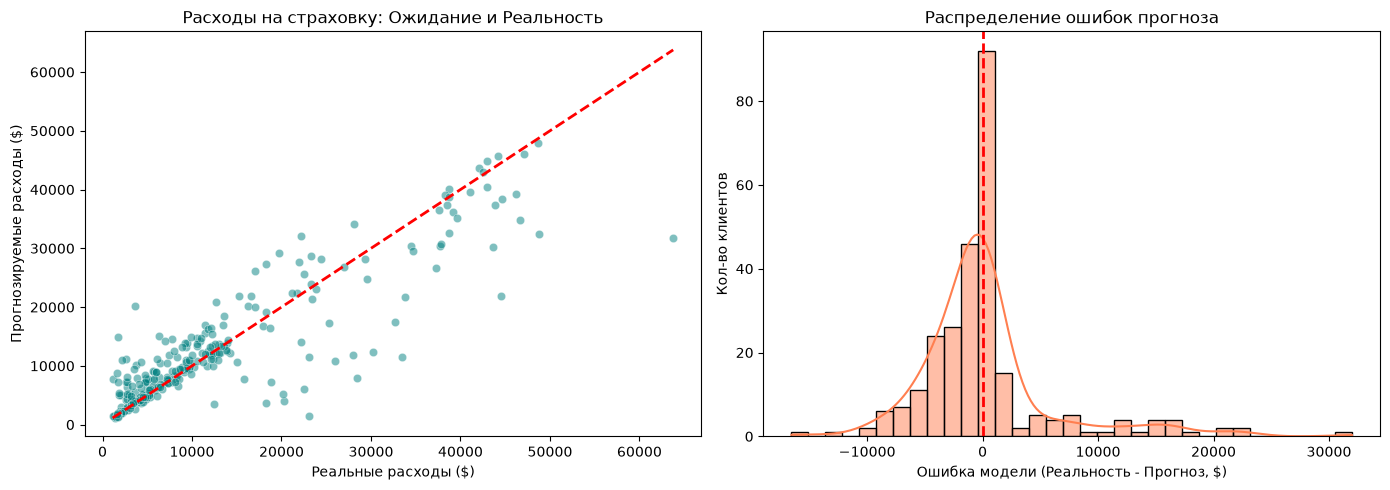

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 График: Факт vs Прогноз
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color="teal", ax=axes[0])
y_min = min(y_test_r.min(), y_pred_r.min())
y_max = max(y_test_r.max(), y_pred_r.max())
axes[0].plot(
    [y_min, y_max], [y_min, y_max], 'r--', lw=2
)
axes[0].set_title("Расходы на страховку: Ожидание и Реальность")
axes[0].set_xlabel("Реальные расходы ($)")
axes[0].set_ylabel("Прогнозируемые расходы ($)")

# 2 График: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', lw=2) # Линия нулевой ошибки
axes[1].set_title("Распределение ошибок прогноза")
axes[1].set_xlabel("Ошибка модели (Реальность - Прогноз, $)")
axes[1].set_ylabel("Кол-во клиентов")

plt.tight_layout()
plt.show()

Вывод: На левом графике дешёвые полисы лежат близко к диагонали, а дорогие — сильно разбросаны и в основном ниже линии, то есть модель занижает высокие расходы. Гистограмма остатков это подтверждает: она смещена вправо от нуля — положительных ошибок больше. Причина в том, что kNN усредняет соседей и «подтягивает» дорогие наблюдения к среднему.

# 8. Финальный вывод
Цель работы — освоить метрики качества, методологию тестирования ML-моделей, сборку пайплайнов для предотвращения утечки данных и автоматизацию подбора гиперпараметров. Всё это решено на датасете страховых выплат.

Первая задача — классификация клиентов по стоимости страховки. Нужно было научить модель отличать дорогой полис от дешёвого. Модель справилась: accuracy = 0.90, ROC-AUC = 0.94. Матрица показала всего 8 ложноположительных и 18 ложноотрицательных ошибок — модель почти не путает классы, а precision и recall держатся около 0.87–0.94. Такой результат даёт weights = 'distance' (ближние соседи важнее) и k = 9 (сглаживает шум, делает границу устойчивой).

Вторая задача — регрессия, предсказание точной суммы. Здесь требовалось выдать конкретную сумму в долларах. Результат: MAE около 3 385 — средний промах, RMSE = 5841 (выше MAE), значит, есть крупные ошибки на дорогих полисах, SMAPE около 29 % — ошибка около трети суммы. Остатки смещены вправо от нуля: модель систематически занижает дорогие выплаты. Причина в kNN — алгоритм усредняет соседей, а при длинном правом хвосте распределения усреднение тянет прогноз к среднему.

Что дала методологическая часть. Pipeline и ColumnTransformer объединили предобработку и модель в один объект — при кросс-валидации StandardScaler и SimpleImputer обучаются только на train-фолде, поэтому утечки данных нет. GridSearchCV и RandomizedSearchCV автоматизировали подбор параметров, а StratifiedKFold и KFold дали честную оценку на нескольких разбиениях.

Общий анализ. Классификация и регрессия на одних и тех же данных дали разный результат: разделить клиентов на две группы проще, чем предсказать точную сумму. Регрессия упирается в ограничения kNN — чувствительность к масштабу, усреднение при выбросах, слабую экстраполяцию на дорогие полисы. Для практического применения такой модели нужно либо добавить признаки (категория ИМТ, взаимодействие «курильщик × возраст», региональные тарифы), либо перейти на градиентный бустинг, который лучше работает с выбросами и нелинейностями. 